# Week 3 Battery Dataset Exploration

This notebook focuses on loading and understanding the MIT-Stanford battery cycle life dataset. The main goal is to inspect one battery cell first, understand the available fields, examine one single cycle, plot discharge curves, and compare capacity fade curves across multiple cells.

## Week 3 Goal

The goal for this week is to load the battery dataset and understand its structure before building any machine learning model. I focus on understanding one cell fully first, including what fields exist, what a single cycle contains, what the discharge curve looks like, and how capacity changes across cycles for multiple cells.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # make the graph

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


In [2]:
batch1_path = "/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat"

## Inspect Batch Structure

The main useful key is `batch`, which contains the battery cell data. Other keys such as `#refs#` and `#subsystem#` are internal MATLAB/HDF5 reference structures. Inside `batch`, each field has shape `(46, 1)`, which means this first batch contains 46 battery cells.

In [3]:
import h5py

batch1_path = "/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat"

with h5py.File(batch1_path, "r") as f:
    print(list(f.keys()))

['#refs#', '#subsystem#', 'batch', 'batch_date']


In [7]:
with h5py.File(batch1_path, "r") as f:
    batch = f["batch"]
    print(type(batch))
    print(list(batch.keys()))

<class 'h5py._hl.group.Group'>
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [8]:
with h5py.File(batch1_path, "r") as f:
    batch = f["batch"]

    for key in batch.keys():
        item = batch[key]
        print(key, type(item), item.shape)

Vdlin <class 'h5py._hl.dataset.Dataset'> (46, 1)
barcode <class 'h5py._hl.dataset.Dataset'> (46, 1)
channel_id <class 'h5py._hl.dataset.Dataset'> (46, 1)
cycle_life <class 'h5py._hl.dataset.Dataset'> (46, 1)
cycles <class 'h5py._hl.dataset.Dataset'> (46, 1)
policy <class 'h5py._hl.dataset.Dataset'> (46, 1)
policy_readable <class 'h5py._hl.dataset.Dataset'> (46, 1)
summary <class 'h5py._hl.dataset.Dataset'> (46, 1)


In [9]:
with h5py.File(batch1_path, "r") as f:
    cycle_life_ref = f["batch"]["cycle_life"][0, 0]
    cycle_life = f[cycle_life_ref][()]
    print(cycle_life)

[[1190.]]


In [10]:
import h5py

cycle_lives = []

with h5py.File(batch1_path, "r") as f:
    for i in range(46):
        ref = f["batch"]["cycle_life"][i, 0]
        life = f[ref][()][0, 0]
        cycle_lives.append(life)

print(cycle_lives)

[np.float64(1190.0), np.float64(1179.0), np.float64(1177.0), np.float64(1226.0), np.float64(1227.0), np.float64(1074.0), np.float64(636.0), np.float64(870.0), np.float64(879.0), np.float64(1054.0), np.float64(906.0), np.float64(788.0), np.float64(902.0), np.float64(897.0), np.float64(880.0), np.float64(719.0), np.float64(862.0), np.float64(857.0), np.float64(691.0), np.float64(788.0), np.float64(534.0), np.float64(559.0), np.float64(891.0), np.float64(1014.0), np.float64(1017.0), np.float64(854.0), np.float64(870.0), np.float64(842.0), np.float64(860.0), np.float64(917.0), np.float64(709.0), np.float64(876.0), np.float64(731.0), np.float64(757.0), np.float64(742.0), np.float64(703.0), np.float64(704.0), np.float64(648.0), np.float64(617.0), np.float64(625.0), np.float64(966.0), np.float64(1051.0), np.float64(702.0), np.float64(651.0), np.float64(616.0), np.float64(599.0)]


In [11]:
import pandas as pd

cycle_life_df = pd.DataFrame({
    "cell_index": range(46),
    "cycle_life": cycle_lives
})

cycle_life_df.head()

,cell_index,cycle_life
0,0,1190.0
1,1,1179.0
2,2,1177.0
3,3,1226.0
4,4,1227.0


# Understanding one Battery Cell Summary
In this section, I inspect one battery cell from the first batch of the MIT-Stanford battery cycle life dataset. The goal is to understand the summary-level data for one cell before analyzing individual cycles or building any machine learning model.


In [4]:
cell_index = 0

In [11]:
with h5py.File(batch1_path, "r") as f:
    cycle_life_ref = f["batch"]["cycle_life"][cell_index, 0]
    cycle_life = f[cycle_life_ref][()][0, 0]

print("Cycle life:", cycle_life)

Cycle life: 1190.0


In [12]:
with h5py.File(batch1_path, "r") as f:
    summary_ref = f["batch"]["summary"][cell_index, 0]
    summary = f[summary_ref]
    
    print(type(summary))
    print(list(summary.keys()))

<class 'h5py._hl.group.Group'>
['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [13]:
with h5py.File(batch1_path, "r") as f:
    summary_ref = f["batch"]["summary"][cell_index, 0]
    summary = f[summary_ref]
    
    for key in summary.keys():
        data = summary[key][()]
        print(key, data.shape, data.dtype)

IR (1, 1189) float64
QCharge (1, 1189) float64
QDischarge (1, 1189) float64
Tavg (1, 1189) float64
Tmax (1, 1189) float64
Tmin (1, 1189) float64
chargetime (1, 1189) float64
cycle (1, 1189) float64


In [14]:
summary_data = {}

with h5py.File(batch1_path, "r") as f:
    summary_ref = f["batch"]["summary"][cell_index, 0]
    summary = f[summary_ref]
    
    for key in summary.keys():
        summary_data[key] = np.array(summary[key]).squeeze()

summary_data.keys()

dict_keys(['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle'])

In [15]:
summary_df = pd.DataFrame(summary_data)

summary_df.head()

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0


In [16]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IR          1189 non-null   float64
 1   QCharge     1189 non-null   float64
 2   QDischarge  1189 non-null   float64
 3   Tavg        1189 non-null   float64
 4   Tmax        1189 non-null   float64
 5   Tmin        1189 non-null   float64
 6   chargetime  1189 non-null   float64
 7   cycle       1189 non-null   float64
dtypes: float64(8)
memory usage: 74.4 KB


In [17]:
summary_df.head()

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0


In [18]:
summary_df.tail()

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
1184,0.017084,1.026296,1.026472,32.305923,36.718185,29.846605,13.341380,1185.0
1185,0.017078,1.026559,1.026700,32.307072,36.600224,29.723915,13.425378,1186.0
1186,0.017085,1.026315,1.026499,32.296148,36.750278,29.727167,13.425498,1187.0
1187,0.017072,1.026620,1.026677,32.208778,36.758877,29.654888,13.340972,1188.0
1188,0.017089,1.026054,1.026210,32.200804,36.561554,29.681129,13.425712,1189.0


# Discharge Capacity vs Cycle number for Cell 0 graph
The plot shows how discharge capacity changes as the cycle number increases. This helps visualize the capacity fade behavior of one battery cell over its lifetime.

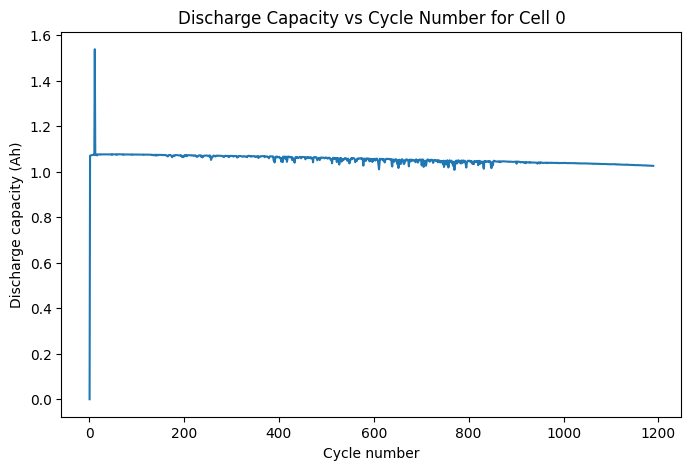

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(summary_df["cycle"], summary_df["QDischarge"])

plt.xlabel("Cycle number")
plt.ylabel("Discharge capacity (Ah)")
plt.title("Discharge Capacity vs Cycle Number for Cell 0")

plt.show()

# Internal Resistance vs Cycle Number for Cell 0

This plot shows the internal resistance of Cell 0 across its cycle life. The internal resistance remains mostly stable around 0.016–0.017 for most cycles, with some sudden drops and spikes that may be caused by measurement noise or abnormal cycles.

Near the later cycles, the internal resistance becomes slightly more unstable and increases a little, which may be related to battery aging. This helps show how summary-level features can describe battery degradation over time.

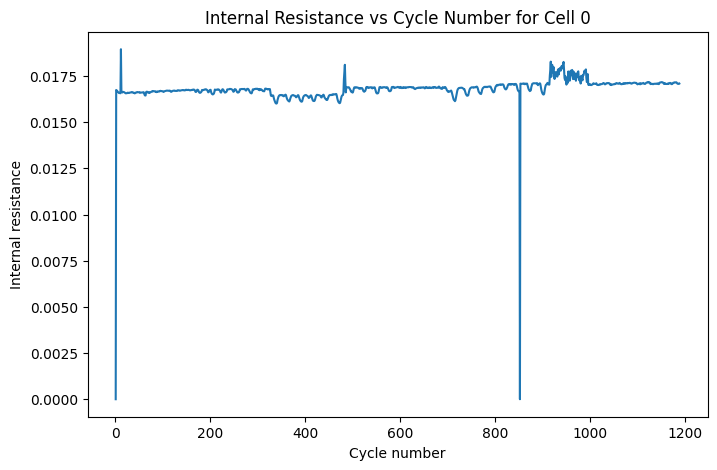

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(summary_df["cycle"], summary_df["IR"])

plt.xlabel("Cycle number")
plt.ylabel("Internal resistance")
plt.title("Internal Resistance vs Cycle Number for Cell 0")

plt.show()

In [21]:
print("Cycle life:", cycle_life)
print("Number of summary rows:", len(summary_df))
print("First cycle:", summary_df["cycle"].iloc[0])
print("Last cycle:", summary_df["cycle"].iloc[-1])
print("First discharge capacity:", summary_df["QDischarge"].iloc[0])
print("Last discharge capacity:", summary_df["QDischarge"].iloc[-1])

Cycle life: 1190.0
Number of summary rows: 1189
First cycle: 1.0
Last cycle: 1189.0
First discharge capacity: 0.0
Last discharge capacity: 1.0262098


# Understand one single cycle and plot a discharge curve

In [8]:
batch1_path = "/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat"

cell_index = 0

In [9]:
with h5py.File(batch1_path, "r") as f:
    cycles_ref = f["batch"]["cycles"][cell_index, 0]
    cycles = f[cycles_ref]

    print(type(cycles))
    print(list(cycles.keys()))

<class 'h5py._hl.group.Group'>
['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']


In [10]:
with h5py.File(batch1_path, "r") as f:
    cycles_ref = f["batch"]["cycles"][cell_index, 0]
    cycles = f[cycles_ref]

    for key in cycles.keys():
        item = cycles[key]
        print(key, type(item), item.shape)

I <class 'h5py._hl.dataset.Dataset'> (1189, 1)
Qc <class 'h5py._hl.dataset.Dataset'> (1189, 1)
Qd <class 'h5py._hl.dataset.Dataset'> (1189, 1)
Qdlin <class 'h5py._hl.dataset.Dataset'> (1189, 1)
T <class 'h5py._hl.dataset.Dataset'> (1189, 1)
Tdlin <class 'h5py._hl.dataset.Dataset'> (1189, 1)
V <class 'h5py._hl.dataset.Dataset'> (1189, 1)
discharge_dQdV <class 'h5py._hl.dataset.Dataset'> (1189, 1)
t <class 'h5py._hl.dataset.Dataset'> (1189, 1)


In [11]:
#choose cycle 10
cycle_index = 9

In [12]:
cycle_index = 9

with h5py.File(batch1_path, "r") as f:
    cycles_ref = f["batch"]["cycles"][cell_index, 0]
    cycles = f[cycles_ref]

    V_ref = cycles["V"][cycle_index, 0]
    Qd_ref = cycles["Qd"][cycle_index, 0]
    I_ref = cycles["I"][cycle_index, 0]
    t_ref = cycles["t"][cycle_index, 0]

    V = np.array(f[V_ref]).squeeze()
    Qd = np.array(f[Qd_ref]).squeeze()
    I = np.array(f[I_ref]).squeeze()
    t = np.array(f[t_ref]).squeeze()

print("V shape:", V.shape)
print("Qd shape:", Qd.shape)
print("I shape:", I.shape)
print("t shape:", t.shape)

V shape: (1130,)
Qd shape: (1130,)
I shape: (1130,)
t shape: (1130,)


In [13]:
print("First 10 voltage values:")
print(V[:10])

print("First 10 discharge capacity values:")
print(Qd[:10])

print("First 10 current values:")
print(I[:10])

print("First 10 time values:")
print(t[:10])

First 10 voltage values:
[2.0231733 2.0380116 2.0511627 2.0629072 2.0767393 2.086771  2.0975628
 2.1091366 2.1273165 2.1403971]
First 10 discharge capacity values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 current values:
[0.         0.25210381 0.39617625 0.50398046 0.61183063 0.68397782
 0.75602878 0.82779451 0.93592555 1.00750927]
First 10 time values:
[0.         0.00265    0.00313167 0.003455   0.00377667 0.003915
 0.00417833 0.00439333 0.00464667 0.00491333]


In [15]:
print("V shape:", V.shape)
print("Qd shape:", Qd.shape)
print("I shape:", I.shape)
print("t shape:", t.shape)

print("Qd min:", Qd.min())
print("Qd max:", Qd.max())

nonzero_qd_indices = np.where(Qd > 0)[0]

print("Number of Qd > 0 points:", len(nonzero_qd_indices))
print("First index where Qd > 0:", nonzero_qd_indices[0])
print("Last index where Qd > 0:", nonzero_qd_indices[-1])

V shape: (1130,)
Qd shape: (1130,)
I shape: (1130,)
t shape: (1130,)
Qd min: 0.0
Qd max: 1.0745373
Number of Qd > 0 points: 442
First index where Qd > 0: 688
Last index where Qd > 0: 1129


In [16]:
start = nonzero_qd_indices[0]

print("First 10 Qd values after discharge starts:")
print(Qd[start:start+10])

print("First 10 V values after discharge starts:")
print(V[start:start+10])

print("First 10 I values after discharge starts:")
print(I[start:start+10])

First 10 Qd values after discharge starts:
[5.0000876e-06 5.0000876e-06 5.0000876e-06 5.0000876e-06 9.7539247e-05
 9.7539247e-05 9.7539247e-05 9.7539247e-05 9.7539247e-05 9.7539247e-05]
First 10 V values after discharge starts:
[3.5897007 3.579236  3.5682898 3.5577946 3.5467405 3.5365686 3.5258417
 3.5148335 3.5023441 3.4921598]
First 10 I values after discharge starts:
[-0.43977477 -0.8799657  -1.31997455 -1.71966855 -2.12012682 -2.47990391
 -2.83979545 -3.19956645 -3.59936891 -3.91949309]


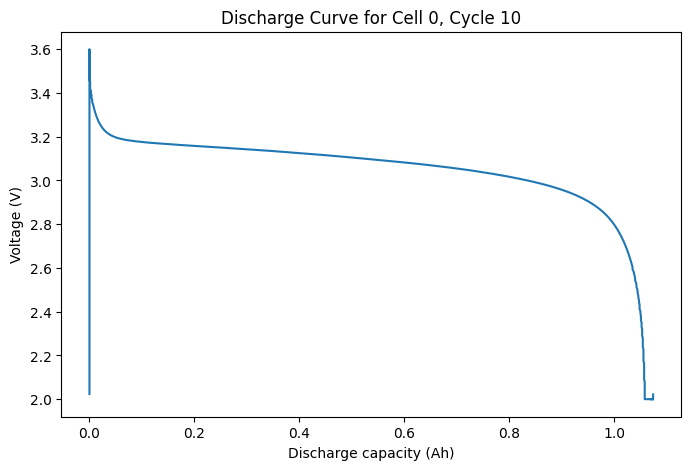

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(Qd, V)

plt.xlabel("Discharge capacity (Ah)")
plt.ylabel("Voltage (V)")
plt.title("Discharge Curve for Cell 0, Cycle 10")

plt.show()

# Discharge Curve for Cell 0, Cycle 10

This graph shows the discharge voltage curve for Cell 0 at Cycle 10. The x-axis represents discharge capacity, and the y-axis represents voltage.

At the beginning of the discharge process, the voltage starts high and then gradually decreases as discharge capacity increases. Near the end of discharge, the voltage drops more sharply. This curve shows that a single cycle contains detailed time-series information, not just one summary value.

This is important because the battery lifetime prediction paper uses early-cycle voltage-capacity curves to create machine learning features for predicting cycle life.

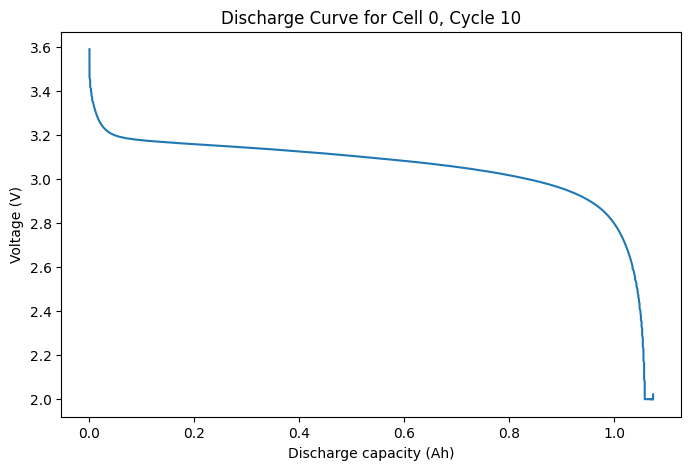

In [18]:
discharge_mask = Qd > 0

plt.figure(figsize=(8, 5))

plt.plot(Qd[discharge_mask], V[discharge_mask])

plt.xlabel("Discharge capacity (Ah)")
plt.ylabel("Voltage (V)")
plt.title("Discharge Curve for Cell 0, Cycle 10")

plt.show()

# Discharge Curves for Cell 0: Cycle 10 vs Cycle 100

This graph compares the discharge voltage curves of Cell 0 at Cycle 10 and Cycle 100. The x-axis represents discharge capacity, and the y-axis represents voltage.

The two curves are very close to each other, which shows that the battery has not experienced obvious capacity degradation during the early cycles. However, there are still small differences between the voltage-capacity curves. These subtle changes are important because the battery lifetime prediction paper uses early-cycle discharge voltage curve differences to create machine learning features.

This comparison helps me understand why early capacity alone may not be enough to predict cycle life, but changes in the voltage curve can still contain useful information about battery aging.

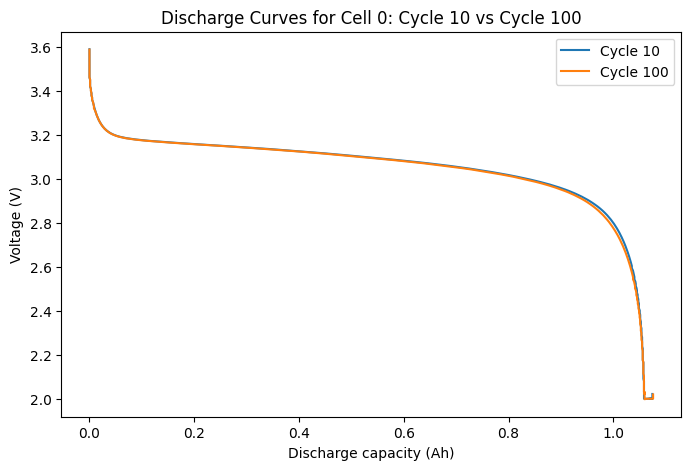

In [19]:
cycle_indices = [9, 99]  # Cycle 10 and Cycle 100

plt.figure(figsize=(8, 5))

with h5py.File(batch1_path, "r") as f:
    cycles_ref = f["batch"]["cycles"][cell_index, 0]
    cycles = f[cycles_ref]

    for cycle_index in cycle_indices:
        V_ref = cycles["V"][cycle_index, 0]
        Qd_ref = cycles["Qd"][cycle_index, 0]

        V = np.array(f[V_ref]).squeeze()
        Qd = np.array(f[Qd_ref]).squeeze()

        discharge_mask = Qd > 0

        plt.plot(Qd[discharge_mask], V[discharge_mask], label=f"Cycle {cycle_index + 1}")

plt.xlabel("Discharge capacity (Ah)")
plt.ylabel("Voltage (V)")
plt.title("Discharge Curves for Cell 0: Cycle 10 vs Cycle 100")
plt.legend()

plt.show()

# Capacity Fade Curves for Multiple Cells

Today, I compare multiple battery cells by plotting discharge capacity versus cycle number. The goal is to see how different cells fade over time and compare the spread in their cycle lives.

In [4]:
cycle_lives = []

with h5py.File(batch1_path, "r") as f:
    num_cells = f["batch"]["cycle_life"].shape[0]
    
    for i in range(num_cells):
        ref = f["batch"]["cycle_life"][i, 0]
        life = np.array(f[ref]).squeeze()
        cycle_lives.append(float(life))

cycle_life_df = pd.DataFrame({
    "cell_index": range(num_cells),
    "cycle_life": cycle_lives
})

cycle_life_df.head()

,cell_index,cycle_life
0,0,1190.0
1,1,1179.0
2,2,1177.0
3,3,1226.0
4,4,1227.0


In [5]:
cycle_life_df.describe()

,cell_index,cycle_life
count,46.000000,46.000000
mean,22.500000,844.717391
std,13.422618,184.629198
min,0.000000,534.000000
25%,11.250000,703.250000
50%,22.500000,858.500000
75%,33.750000,914.250000
max,45.000000,1227.000000


In [6]:
cycle_life_df.sort_values("cycle_life").head()

,cell_index,cycle_life
20,20,534.0
21,21,559.0
45,45,599.0
44,44,616.0
38,38,617.0


In [7]:
cycle_life_df.sort_values("cycle_life").tail()

,cell_index,cycle_life
2,2,1177.0
1,1,1179.0
0,0,1190.0
3,3,1226.0
4,4,1227.0


In [8]:
sorted_cells = cycle_life_df.sort_values("cycle_life").reset_index(drop=True)

selected_cells = [
    int(sorted_cells.iloc[0]["cell_index"]),    # shortest life
    int(sorted_cells.iloc[10]["cell_index"]),
    int(sorted_cells.iloc[20]["cell_index"]),
    int(sorted_cells.iloc[30]["cell_index"]),
    int(sorted_cells.iloc[-1]["cell_index"])    # longest life
]

selected_cells

[20, 42, 27, 22, 4]

In [9]:
cycle_life_df[cycle_life_df["cell_index"].isin(selected_cells)].sort_values("cycle_life")

,cell_index,cycle_life
20,20,534.0
42,42,702.0
27,27,842.0
22,22,891.0
4,4,1227.0


In [11]:
def get_summary_df(f, cell_index):
    summary_ref = f["batch"]["summary"][cell_index, 0]
    summary = f[summary_ref]
    
    summary_data = {}
    
    for key in summary.keys():
        summary_data[key] = np.array(summary[key]).squeeze()
    
    return pd.DataFrame(summary_data)

In [12]:
with h5py.File(batch1_path, "r") as f:
    test_df = get_summary_df(f, 0)

test_df.head()

,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0


# Capacity Fade Curves for Selected Battery Cells

This graph shows discharge capacity versus cycle number for several selected battery cells. Each line represents one cell, and the legend shows the cycle life of each cell.

The cells have different cycle lives, so some curves end earlier while others continue for more cycles. This shows the spread in battery lifetimes across different cells. The discharge capacity stays relatively stable during the early cycles, but it eventually decreases as the cells age.

This plot helps me understand capacity fade behavior and why cycle life prediction is useful for comparing batteries with different degradation patterns.

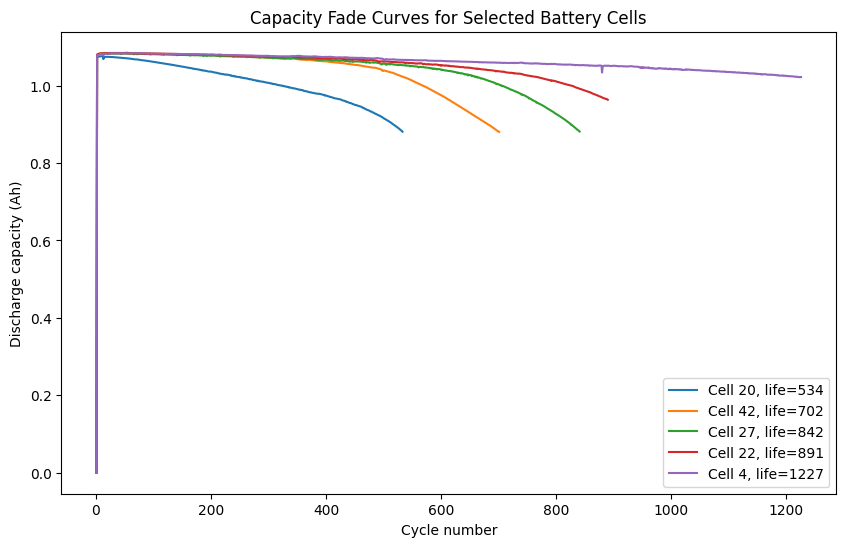

In [13]:
plt.figure(figsize=(10, 6))

with h5py.File(batch1_path, "r") as f:
    for cell_index in selected_cells:
        summary_df = get_summary_df(f, cell_index)
        
        life = cycle_life_df.loc[
            cycle_life_df["cell_index"] == cell_index, 
            "cycle_life"
        ].values[0]
        
        plt.plot(
            summary_df["cycle"], 
            summary_df["QDischarge"], 
            label=f"Cell {cell_index}, life={int(life)}"
        )

plt.xlabel("Cycle number")
plt.ylabel("Discharge capacity (Ah)")
plt.title("Capacity Fade Curves for Selected Battery Cells")
plt.legend()
plt.show()

**Observation:**  
The selected cells show different lifetime behavior. Some cells reach the end of life earlier, while others maintain capacity for more cycles. Although the early-cycle capacity curves look similar, the long-term outcomes are different. This connects to the paper's idea that early capacity alone may not be enough to predict lifetime.

## Final Observations for Week 3

This week, I successfully loaded the MIT-Stanford battery cycle life dataset in Kaggle and inspected the structure of the first batch file. I learned that the first batch contains 46 battery cells, and each cell has fields such as `cycle_life`, `summary`, `cycles`, and `policy`.

I first focused on Cell 0 and read its cycle life, summary data, and cycle-level data. From the summary data, I plotted discharge capacity and internal resistance across cycles. From the cycle-level data, I plotted the discharge voltage curve for one cycle and compared discharge curves between Cycle 10 and Cycle 100.

I also plotted capacity fade curves for multiple cells to compare their lifetime behavior. The results show that some cells degrade earlier than others, and early-cycle capacity alone does not clearly show the future cycle life. This connects to the paper's main idea that more detailed early-cycle voltage curve features may be useful for predicting battery lifetime.